<a href="https://colab.research.google.com/github/tacla/Sistemas-Inteligentes/blob/main/CART/Classificador_Valid_Cruzada_CART.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CLASSIFICAÇÃO & VALIDAÇÃO CRUZADA
**Objetivo**: Explorar um algoritmo de aprendizado de máquina para compreender o método de validação cruzada e as métricas utilizadas para avaliar um modelo de classificação. Vamos iniciar pela importação das bibliotecas.

In [83]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

**(1) Geração de um dataset artificial**

[Make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html?highlight=make_moons#sklearn.datasets.make_moons) gera duas nuvens de pontos entrelaçadas ou não (ver parâmetro *noise*) utilizando duas características: x0 e x1 (*features de entrada*). Para cada amostra, make_moons gera uma classe de saída binária (`y E {0, 1}`). Isto significa que trabalharemos com exemplos positivos e negativos o que é chamado de aprendizado de conceito.

In [84]:
# make_moons serve para gerar datasets sintéticos para testes.
# Make moons gera duas regioes circulares de exemplos positivos e negativos

# shuffle: boolean - embaralhar ou nao as amostras
# noise: desvio padrao de ruido Gaussiano
# random_star: se for int produz saidas identicas quando invocado diversas vezes
# Xm é um array de duas colunas [x0 x1] por m linhas = n_samples
Xm, ym = make_moons(n_samples=1000, noise=0.3, random_state=42)
Xy = [[x0, x1, y] for x0, x1, y in zip(Xm[:,0], Xm[:,1], ym)]

# transforma os arrays Xm e ym em um dataframe do pandas
df = pd.DataFrame(Xy, columns = ['x0','x1','y'])
print("Amostras iniciais do dataframe")
print(df.head(3)) # imprime 3 amostras do dataframe

Amostras iniciais do dataframe
         x0        x1  y
0 -0.171863  0.596249  1
1  1.253283 -0.265414  1
2  0.723224  0.231943  1


**(2) Plotar as amostras**

Observar que as amostras formam duas regiões circulares com sobreposição definida pelo argumento *noise* em *make_moons*.

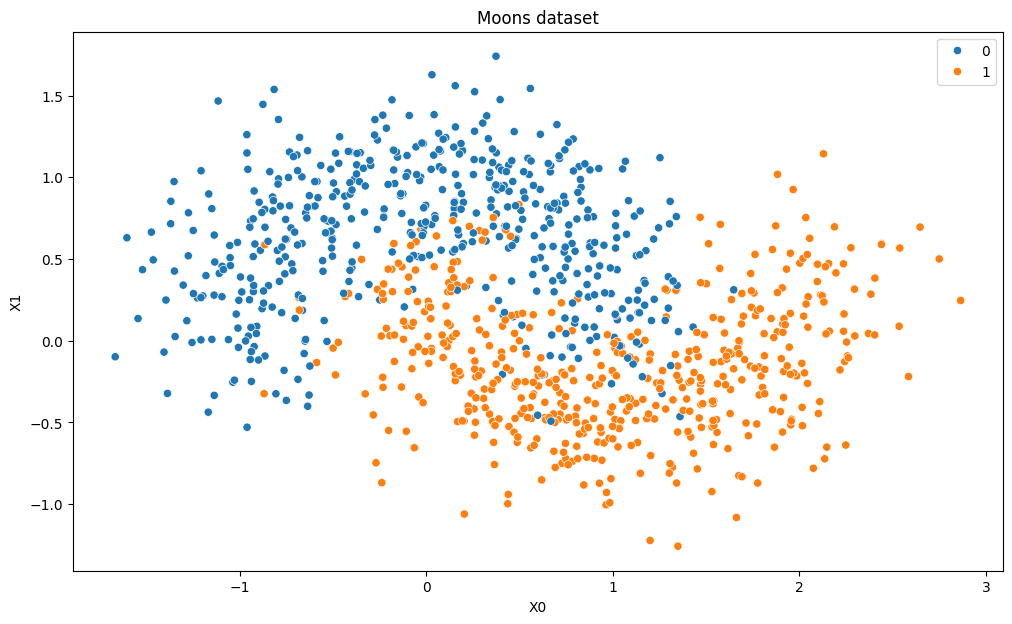

In [85]:
# plot data
plt.figure(figsize=(12,7))

gr = sns.scatterplot(data=df, x="x0", y="x1", hue="y")
gr.set_title("Moons dataset")
plt.xlabel('X0')
plt.ylabel('X1')
plt.legend()
plt.show()

**(3) Validação cruzada**

É um método para treinar/validar e testar modelos de aprendizado para evitar a sobreadaptação (*overfitting*) às amostras de treinamento.

SciKit possibilita separar o dataset em partes justamente para evitar este problema. Vamos fracionar o dataset em duas partes:
1.   para treinamento e validação
2.   para testes com dados não utilizados em 1


**Parêmetros importantes**:
* *test_size*: qual fração do dataset será reservado para testes (entre 20-30%)
* *shuffle*: boolean; embaralha ou não antes de dividir (recomendável true)

Você pode fazer o fracionamento do dataset manualmente com a função *train_test_split*.

Vamos dividir o dataset em 70% para treinamento/validação e 30% para testes.
Documentação: [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split)

In [86]:
## Dividir o dataset em treinamento/validação e teste
X_train, X_test, y_train, y_test = train_test_split(Xm, ym, test_size=0.25, shuffle=True)
print(f"Tamanho total do dataset: {len(Xm)}\n")
print(f"Dados de treinamento X ({len(X_train)}):\n{X_train[:3]} ...")
print(f"Dados de treinamento y:({len(y_train)})\n {y_train[:3]} ...")
print("---")
print(f"Dados de teste   X ({len(X_test)}):\n{X_test[:3]} ...")
print(f"Dados de teste   y:({len(y_test)})\n {y_test[:3]} ...")

Tamanho total do dataset: 1000

Dados de treinamento X (750):
[[ 0.72663099 -0.1002609 ]
 [ 0.64994318  0.82023516]
 [ 0.8610141   0.34384312]] ...
Dados de treinamento y:(750)
 [0 0 0] ...
---
Dados de teste   X (250):
[[-0.27047161 -0.74676241]
 [ 1.5303518  -0.92303624]
 [ 0.92880126  0.45800221]] ...
Dados de teste   y:(250)
 [1 1 0] ...


# **(4) Experimento**

Cada experimento consiste em utilizar *n parametrizações* diferentes do algoritmo em k *folds* (fracionamentos)

No nosso caso, vamos fazer [4 parametrizações diferentes](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) para a árvore de decisão que resulta de todas as combinações dos parâmetros abaixo:
* ***criterio***: `entropia`
* ***max_depth***: profundidade máxima da árvore: `[10, 20]`
* ***min_samples_leaf***:  número mínimo de amostras por folha; pode acabar descartando ramificações de nós não folha: `[4, 8]`

```
Em cada experimento de treinamento
- para cada uma das parametrizações
  - executa-se o algoritmo de treinamento para cada fold

```

No nosso experimento temos 6 parametrizações e vamos utilizar 3-folds. Logo, para cada parametrização o algoritmo de treinamento é executado 3 vezes, totalizando 18 execuções.

Vamos utilizar a função [GridSearchCV](https://colab.research.google.com/drive/1hSrqmmzphUlQRXmA__VMaged20a_tH1f?authuser=2#scrollTo=flNYY1YgSiea&line=11&uniqifier=1) que faz todas as combinações dos parâmetros e, também, a validação cruzada(CV) com 3 folds.

A **saída do código** produz uma linha por parametrização e por fold.

O **score** de comparação para a escolha do melhor modelo pode ser escolhido (ver opções neste [link](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)). No exemplo, vamos utilizar o f1 (média harmônica entre precisão e recall). Observe na saída que cada linha corresponde a um fold, por exemplo, CV 1/3 é o fold 1 de 3.

`F1 = 2 * (precision * recall) / (precision + recall)`

---



In [87]:
parameters = {
    'criterion': ['entropy'],
    'max_depth': [2, 4],
    'min_samples_leaf': [8, 16, 32]
}

# instantiate model
model = DecisionTreeClassifier(random_state=42)

# grid search using cv
#clf = GridSearchCV(model, parameters, cv=3, scoring='f1', verbose=4)
n_folds = 3
clf = GridSearchCV(model, parameters, cv=n_folds, scoring='f1', return_train_score=True)

# treinamento e validação
clf.fit(X_train, y_train)

# para ecolhermos o melhor modelo
all_models = []

# resultados
res = clf.cv_results_
for i, params in enumerate(res['params']):
    print(f"\nParâmetros: {params}")

    # F1 para treino e validação
    train_scores = np.array([res[f'split{f}_train_score'][i] for f in range(n_folds)])
    val_scores = np.array([res[f'split{f}_test_score'][i] for f in range(n_folds)])

    # cálculos para escolha do melhor modelo
    val_mean = np.mean(val_scores)
    val_std = np.std(val_scores)

    # Formatação dos valores de F1
    train_formatted = [f"{v:.5f}" for v in train_scores]
    val_formatted = [f"{v:.5f}" for v in val_scores]
    print(f"Treino:    F1 por fold: {train_formatted} = {np.mean(train_scores):.5f} +-{np.std(train_scores):.5f}")
    print(f"Validação: F1 por fold: {val_formatted} = {val_mean:.5f} +-{val_std:.5f}")

    # viés: f1_treino - f1_valid
    dif = (np.abs(train_scores - val_scores))
    dif_mean = np.mean(dif)
    dif_std = np.std(dif)

    # Print para cada fold
    dif_formatted = [f"{g:.5f}" for g in dif]
    print(f"Diferenças abs........: {dif_formatted}")
    print(f"Média das diferenças..: {dif_mean:.5f}")
    print(f"DPadrão das diferenças: {dif_std:.5f}")

    # salva para posterior escolha do melhor (método próprio)
    all_models.append({
        'params': params,
        'val_mean': val_mean,
        'val_std': val_std,
        'dif_mean': dif_mean
    })


Parâmetros: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 8}
Treino:    F1 por fold: ['0.86710', '0.88764', '0.89162'] = 0.88212 +-0.01074
Validação: F1 por fold: ['0.85837', '0.88636', '0.87903'] = 0.87459 +-0.01185
Diferenças abs........: ['0.00873', '0.00128', '0.01258']
Média das diferenças..: 0.00753
DPadrão das diferenças: 0.00469

Parâmetros: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 16}
Treino:    F1 por fold: ['0.85463', '0.87941', '0.89162'] = 0.87522 +-0.01539
Validação: F1 por fold: ['0.84348', '0.86989', '0.87903'] = 0.86413 +-0.01507
Diferenças abs........: ['0.01115', '0.00952', '0.01258']
Média das diferenças..: 0.01108
DPadrão das diferenças: 0.00125

Parâmetros: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 32}
Treino:    F1 por fold: ['0.84681', '0.86424', '0.86957'] = 0.86021 +-0.00972
Validação: F1 por fold: ['0.85000', '0.86047', '0.85714'] = 0.85587 +-0.00437
Diferenças abs........: ['0.00319', '0.00378', '0.01242

# (5) Escolha do melhor modelo
O método `best_estimator_` do GridSearchCV olha apenas para a maior média do f1 de validação, o que nem sempre é a melhor escolha. Neste caso específico, o método retorna o primeiro modelo que é o mesmo retornado pelo método próprio.

O método próprio filtra os modelos que tem a mesma média de F1 na validação dentro de uma faixa +-0.005. Para os modelos que filtrados, deesempata ordenando os candidatos pelos critérios de prioridade:

1º: Menor desvio padrão da média de f1 na validação (val_std)

2º: Menor diferença treino-validação (dif_mean)

3º: Maior F1 de validação (val_mean)







In [88]:
# Scikit: melhor modelo = o que obteve melhor f1 na validação
# este é o modo que o gridSearchCV funciona, ele despreza as diferenças treino
# e validação. No caso de empate, pega o primeiro modelo.
best = clf.best_estimator_
print("\n* Melhor classificador Scikit *")
print(f"Parâmetros ..............: {clf.best_params_}")
print(f"Média F1 de validação....: {clf.best_score_:.5f}")

# escolha pelos critérios que seguem: maior F1
# Maior F1
max_f1 = max(m['val_mean'] for m in all_models)

# seleciona os modelos que estão no "empate técnico" (margem de 0.005)
candidates = [m for m in all_models if m['val_mean'] >= (max_f1 - 0.005)]

# Desempata ordenando os candidatos pelos critérios de prioridade:
# 1º: Menor desvio padrão da média de f1 na validação (val_std)
# 2º: Menor diferença treino-validação (dif_mean)
# 3º: Maior F1 de validação (val_mean)
best_model = sorted(
    candidates,
    key=lambda x: (x['val_std'], x['dif_mean'], -x['val_mean'])
)[0]

print("\n* Melhor modelo próprio *")
print(f"Parâmetros: {best_model['params']}")
print(f"Validação média de F1........: {best_model['val_mean']:.5f}")
print(f"Validação desvio padrão......: {best_model['val_std']:.5f}")
print(f"média das difs |treino-valid|: {best_model['dif_mean']:.5f}")


* Melhor classificador Scikit *
Parâmetros ..............: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 8}
Média F1 de validação....: 0.87459

* Melhor modelo próprio *
Parâmetros: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 8}
Validação média de F1........: 0.87459
Validação desvio padrão......: 0.01185
média das difs |treino-valid|: 0.00753


**(5) Testar o modelo aprendido**

Agora, é possível rodar o modelo aprendido com os dados de teste cego (reservados anteriormente) e verificarmos as métricas de classificação.

Se a acurácia do treinamento/validação estiver muito maior do que a do teste, é um indício de que o modelo está sobreadaptado.


In [89]:
# Predicoes
# com dados do treinamento
y_pred_train = best.predict(X_train)
acc_train = accuracy_score(y_train, y_pred_train) * 100
print(f"Acuracia com dados de treino: {acc_train:.2f}%")

# com dados de teste
y_pred_test = best.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test) * 100
print(f"Acuracia com dados de teste: {acc_test:.2f}%")

Acuracia com dados de treino: 89.07%
Acuracia com dados de teste: 91.20%


## ÁRVORE DE DECISÃO (MODELO APRENDIDO)

Agora vamos visualizar a árvore de melhor desempenho e algumas métricas para avaliar classificadores:
- matriz de confusão,
- precisão,
- recall e
- f-measure.

Na figura abaixo, observe em cada nó:
* **X0 <= valor** : condição para uma amostra ser classificada em um ramo da árvore
* **entropy**: valor da entropia para o nó (nós folhas normalmente = zero)
* **value**: [amostras da classe 0, amostras da classe 1]
* **class**: mostra a classe mais numerosa do nó

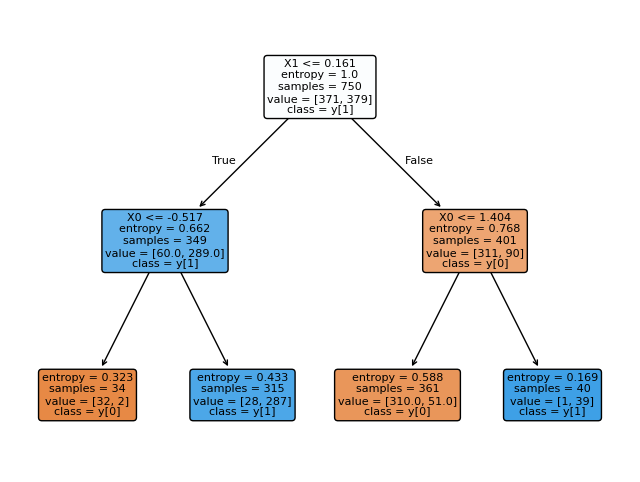

In [90]:
from sklearn import tree
fig = plt.figure(figsize=(8, 6))
tree.plot_tree(best, feature_names=["X0", "X1"], filled=True, rounded=True, class_names=True, fontsize=8)
plt.show()

### MÉTRICAS PARA CLASSIFICADORES
Vamos analisar os resultados do teste.

***Matriz de confusão***: mostra o número de classificações corretas na diagonal principal. A partir dela, pode-se calcular precision, recall, taxa de verdadeiros positivos, ...

***Precision***: dentre os classificados como sendo classe zero quantos realmente são (idem para classe 1).

***Recall***: dentre todos os sabidos classe zero, quantos foram classificados como tal  (idem para classe 1).

***f1-score***: média harmônica entre precision e recall.

Todas estas métricas podem ser ponderadas pelo número de amostras de cada classe.
   

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       129
           1       0.90      0.93      0.91       121

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



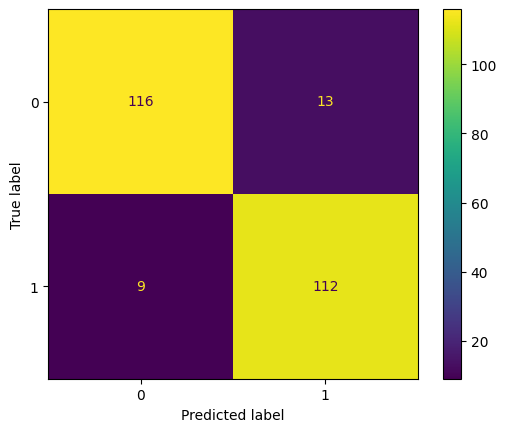

In [91]:
# Matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
print(classification_report(y_test, y_pred_test))


---

### **MATRIZ DE CONFUSÃO, PRECISION, RECALL E F1**

Vamos fazer uma matriz com dados estáticos para fins didáticos.
Considere que temos 5 amostras da classe 0 e 7 da classe 1. O classificador acerta:
* 4 da classe 0 (esses são os verdadeiros positivos)
* 5 da classe 1

Lendo coluna a coluna para calcularmos a precisão por classe (rode o código abaixo e veja a figura).

**Precisão = VP / (VP + FP)**
* classe 0, **Precisão, P0** = 4/6 = 0,666
* classe 1, **Precisão, P1** = 5/6 = 0,833
* média: 0,75

Lendo linha a linha para calcularmos o recall por classe:

**Recall = VP / (VP + FN)**
* classe 0, **Recall, R0** = 4/5 = 0,800
* classe 1, **Recall, R1** = 5/7 = 0,714
* média: 0,757
* média ponderada: (5.R0 + 7.R1)/12 = 0,75

**f1**
* classe 0: 2.P0.R0/(P0+R0) = 0,726
* classe 1: 2.P1.R1/(P1+R1) = 0,768
* média: 0,747
* f1 ponderado: (5.f1_0 + 7.f1_1)/12 = 0,7505

**Acuracidade geral**: 9/12 = 0,75


VP = Verdadeiro Positivo; FP = Falso Positivo; FN = Falso Negativo

              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.83      0.71      0.77         7

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12



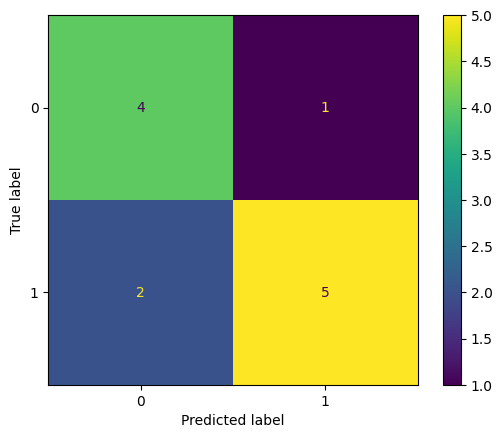

In [92]:
y_true = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred = [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0]
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
print(classification_report(y_true, y_pred))

---
FIM
---